In [1]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/fish01.csv")
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
# 데이터 읽기
# 컬럼변경
# 타입변경
# x, y 특성, 타겟 변수 설정
# 훈련용 테스트용 데이터 분할
# 스탠다스 스케일링

In [2]:
df.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [4]:
t1 = dict(zip(df.columns, ['종류', '무게', '길이', '대각선', '높이', '넓이']))
t1

{'Species': '종류',
 'Weight': '무게',
 'Length': '길이',
 'Diagonal': '대각선',
 'Height': '높이',
 'Width': '넓이'}

In [6]:
df1 = df.rename(columns=t1)
df1.head()

,종류,무게,길이,대각선,높이,넓이
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [7]:
df1['종류'].value_counts()

종류
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [15]:
x = df1[['무게', '길이', '대각선', '높이', '넓이']].values
y = df1['종류'].values

In [19]:
print(x[:5], y[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]] ['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=123, train_size=0.8)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((127, 5), (32, 5), (127,), (32,))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled.shape, x_test_scaled.shape

((127, 5), (32, 5))

In [ ]:
# log_loss는 로지스틱 회귀 손실함수

# loss는 실제값 - 오차값을 비교, 학습횟수 100번, 학습률도 있는데 여기에서는 지금 없음

from sklearn.linear_model import SGDClassifier
model = SGDClassifier(loss="log_loss", max_iter=100, random_state=123)
model.fit(x_train_scaled, y_train)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
# 1번 훈련한 결과
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(0.8582677165354331, 0.90625)

In [55]:
# 누적훈련
model.partial_fit(x_train_scaled, y_train)
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(0.9291338582677166, 0.96875)

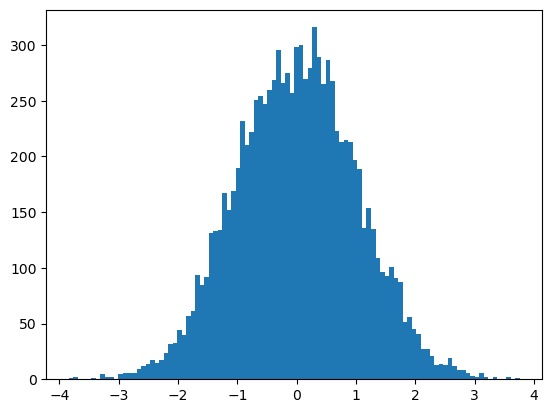

In [ ]:
# 모델 => 저장 => 숫자(가중치)
# 특성 => 가중치 w
# 정규분포

import tensorflow as tf
import matplotlib.pyplot as plt

random_normal = tf.random.normal([10000], mean=0, stddev=1)
plt.hist(random_normal, bins=100)
plt.show()

In [62]:
random_normal[:100]

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([-0.9521394 ,  1.6217135 ,  0.11825979, -0.22398436, -0.3134834 ,
        0.519576  ,  0.28847605,  1.1309161 ,  0.6863719 ,  0.36227784,
       -1.0683672 , -1.7358997 ,  1.7497481 ,  1.3989737 ,  1.0177307 ,
       -1.5721048 , -0.6608159 ,  1.8260342 ,  1.5453135 ,  0.10867203,
       -0.8620444 , -1.0022825 ,  0.47777024, -0.53170407,  0.26461983,
       -1.1352369 ,  2.2494023 , -1.222851  , -0.10145541,  2.0008287 ,
        1.0657358 , -2.0541945 , -1.036448  , -0.10935569,  0.17000803,
        1.204958  ,  0.40919486, -1.9824077 , -0.27909142,  0.2958829 ,
        0.0187848 ,  0.40348527, -0.4073655 , -0.57992005, -0.89928234,
       -0.92492074, -0.09043564,  0.49533644, -1.2748601 ,  1.001858  ,
        0.02345581, -0.25835308,  0.42659834, -0.48952234, -1.0773879 ,
       -0.4942406 ,  0.54308033,  0.4699085 ,  0.6110592 , -0.28749982,
        1.8720798 , -1.8936971 , -0.2204309 ,  1.5177553 ,  0.01702674,
        0.271492

In [ ]:
# x의 값은 1이고 결과값은 0이 되는
x = 1
y = 0

# 가중치 x에 곱해지는 값
w = tf.random.normal([1], mean=0, stddev=1)

# bias x에 대해지는 값 x가 0일경우 변화없음 에서 탈출하기 위해
b = tf.random.normal([1], mean=0, stddev=1)

x, y, w, b

(1,
 0,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.1274613], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.22117303], dtype=float32)>)

In [ ]:
import numpy as np

def sigmoid(x):
    return 1/ (1 + np.exp(-x))

# 학습횟수 1000에포크 epoch
for i in range(1000):
    output = sigmoid(x * w + (1 + b)) # 여기에서는 b가 0일 수 있어서 1을 추가
    error = y - output # loss = error
    w = w + (x * 0.1 * error)
    b = b + (1 * 0.1 * error)
    print(i, output, error)

In [153]:
import numpy as np

# x가 두개 이므로 가중치 w두개가 필요
x = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0],
])

y = np.array([[0], [1], [1], [0]])

# x가 두개 이므로 가중치 w두개가 필요
w = tf.random.normal([2], mean=0, stddev=1)
b = tf.random.normal([1], mean=0, stddev=1)

# 특성이 (n, 2) => (n, 1)
x.shape, y.shape

((4, 2), (4, 1))

In [149]:
x, y, w, b

(array([[1, 1],
        [1, 0],
        [0, 1],
        [0, 0]]),
 array([[1],
        [1],
        [1],
        [0]]),
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1.289525  , 0.32778546], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-1.6089655], dtype=float32)>)

In [ ]:
# 2000번 에포크 학습
for i in range(2000):
    for j in range(4):
        # output = x1 *l w1 + x2 * w2 + b
        output = sigmoid(x[j][0] * w[0] + x[j][1] * w[1] + (1 * b))
        error = y[j][0] - output
        w = w + x[j] * 0.1 * error # 가중치 두개 동시에 한다
        b = b + 1 * 0.1 * error
    if i % 100 == 99:
        print(i, error, output)

In [ ]:
# 예측하기
for i in range(4):
    output = sigmoid(x[i][0] * w[0] + x[i][1] * w[1] + (1 * b))
    print(x[i], y[i], output)


[1 1] [0] [0.5128176]
[1 0] [1] [0.5128176]
[0 1] [1] [0.5]
[0 0] [0] [0.50000006]


# Bonus XOR: Hidden Layer

In [161]:
import numpy as np

# 1. Activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(activated_x):
    # Takes the already sigmoid-activated matrix to calculate gradient
    return activated_x * (1 - activated_x)

# 2. XOR training data (Inputs and Expected Outputs)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0], 
              [1], 
              [1], 
              [0]])

# Seed random numbers for reproducibility
np.random.seed(42)

# 3. Initialize hyperparameters, weights, and biases
epochs = 10000
lr = 0.5  # Learning rate

# Weights & Biases for Hidden Layer (2 input nodes -> 2 hidden nodes)
wh = np.random.uniform(size=(2, 2))
bh = np.random.uniform(size=(1, 2))

# Weights & Biases for Output Layer (2 hidden nodes -> 1 output node)
wout = np.random.uniform(size=(2, 1))
bout = np.random.uniform(size=(1, 1))

# 4. Training Loop (Gradient Descent)
for epoch in range(epochs):
    
    # --- Forward Pass ---
    hidden_input = np.dot(X, wh) + bh
    hidden_output = sigmoid(hidden_input)
    
    final_input = np.dot(hidden_output, wout) + bout
    predicted_output = sigmoid(final_input)
    
    # --- Backward Pass (Backpropagation) ---
    # Output layer error and gradient calculation
    error_output = y - predicted_output
    gradient_output = error_output * sigmoid_derivative(predicted_output)
    
    # Hidden layer error and gradient calculation
    error_hidden = gradient_output.dot(wout.T)
    gradient_hidden = error_hidden * sigmoid_derivative(hidden_output)
    
    # --- Update Weights and Biases ---
    wout += hidden_output.T.dot(gradient_output) * lr
    bout += np.sum(gradient_output, axis=0, keepdims=True) * lr
    wh += X.T.dot(gradient_hidden) * lr
    bh += np.sum(gradient_hidden, axis=0, keepdims=True) * lr

# 5. Output Final Results
print("Final Predicted XOR Outputs (should be close to 0, 1, 1, 0):")
print(np.round(predicted_output, 4))


Final Predicted XOR Outputs (should be close to 0, 1, 1, 0):
[[0.0189]
 [0.9837]
 [0.9837]
 [0.0169]]
